<a href="https://colab.research.google.com/github/Chrisboo-zzz/fly/blob/main/examples/03_flyvision_flash_responses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flash responses

This notebook introduces flash responses and the flash response index (FRI).

The FRI measures whether a cell depolarizes to bright or to dark increments in a visual input.

**Select GPU runtime**

To run the notebook on a GPU select Menu -> Runtime -> Change runtime type -> GPU.

In [1]:
# @markdown **Check access to GPU**

try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import torch

    try:
        cuda_name = torch.cuda.get_device_name()
        print(f"Name of the assigned GPU / CUDA device: {cuda_name}")
    except RuntimeError:
        import warnings

        warnings.warn(
            "You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow)."
        )

/tmp/ipython-input-96976449.py:19: UserWarning: You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow).
  warnings.warn(


**Install Flyvis**

The notebook requires installing our package `flyvis`. You may need to restart your session after running the code block below with Menu -> Runtime -> Restart session. Then, imports from `flyvis` should succeed without issue.

In [2]:
# @markdown **Install Flyvis**
if IN_COLAB:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]

fatal: destination path 'flyvis' already exists and is not an empty directory.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for flyvis (pyproject.toml) ... done
  Created wheel for flyvis: filename=flyvis-1.1.3.dev4+gfd4a4cbb6-0.editable-py3-none-any.whl size=5551 sha256=c024885f25525f4815e516c69b81a9be01be17e3d68f1b627feceeab9f9666e2
  Stored in directory: /tmp/pip-ephem-wheel-cache-l5ukcdh5/wheels/a1/6b/fa/70710426acf06fdb8c9fd11c637657f14ee995d52108f68ac4
Successfully built flyvis
  Attempting uninstall: flyvis
    Found existing installation: flyvis 1.1.3.dev4+gfd4a4cbb6
    Uninstalling flyvis-1.1.3.dev4+gfd4a4cbb6:
      Successfully uninstalled flyvis-1.1.3.dev4+gfd4a4cbb6


## Flash stimuli

To elicit flash responses, experimenters show a flashing dot to the subject in the center of their field of view. We generate and render these stimuli with the `Flashes` dataset.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch


from flyvis.analysis.animations.hexscatter import HexScatter
from flyvis.datasets.flashes import Flashes

In [9]:
class BrightFlash4Dataset(Flashes):
    def __init__(self, **kwargs):
        # 使用 dynamic_range=[1, 1] 确保只生成亮的样本
        kwargs['dynamic_range'] = [1, 1]
        super().__init__(**kwargs)

        # 用flash4模式替换数据
        self._replace_with_flash4()

        # 更新arg_df，baseline为0.5
        self.arg_df = pd.DataFrame([{
            'baseline': 0.5,  # 基线为0.5
            'intensity': 1.0,  # 闪光时为1.0
            'radius': -1,
            'stim_type': 'flash4_bright'
        }])

    def _replace_with_flash4(self):
        total_frames = 650
        n_ommatidia = self.flashes_dir.flashes.shape[-1]

        # 创建flash4刺激模式 - 从0.5开始
        stim = np.full(total_frames, 0.5)  # 全部初始化为0.5
        periods = [(199, 229), (255, 285), (312, 342), (370, 400)]
        for start, end in periods:
            stim[start:end] = 1.0  # 闪光时变为1.0

        # 创建刺激数据
        stimulus_data = []
        for intensity in stim:
            frame = np.full(n_ommatidia, intensity, dtype=np.float32)
            stimulus_data.append(frame)

        stimulus_array = np.array(stimulus_data)  # (650, n_ommatidia)
        stimulus_array = stimulus_array[np.newaxis, :, :]  # (1, 650, n_ommatidia)

        # 替换数据
        self.flashes_dir.flashes = stimulus_array

    def __len__(self):
        return 1

    def get_item(self, key: int):
        if key == 0:
            return torch.tensor(self.flashes_dir.flashes[0], dtype=torch.float32)
        else:
            raise IndexError("只有一个样本")

# 使用
dataset = BrightFlash4Dataset(
    t_stim=0.30,
    t_pre=1.99,
    dt=1/100,
    radius=[-1],
    alternations=(0, 1),
)

print(f"数据集样本数: {len(dataset)}")
print(f"参数表: {dataset.arg_df}")

/usr/local/lib/python3.12/dist-packages/datamate/directory.py:255: ModifiedWarning: Skipping Directory /content/flyvis/data/renderings/RenderedFlashes_0014, which has been modified after  being build.
You can use the explicit path as constructor (see  Directory docs).
  cls = _directory_from_config(cls, config)
/usr/local/lib/python3.12/dist-packages/datamate/directory.py:255: ModifiedWarning: Skipping Directory /content/flyvis/data/renderings/RenderedFlashes_0013, which has been modified after  being build.
You can use the explicit path as constructor (see  Directory docs).
  cls = _directory_from_config(cls, config)
/usr/local/lib/python3.12/dist-packages/datamate/directory.py:255: ModifiedWarning: Skipping Directory /content/flyvis/data/renderings/RenderedFlashes_0012, which has been modified after  being build.
You can use the explicit path as constructor (see  Directory docs).
  cls = _directory_from_config(cls, config)
/usr/local/lib/python3.12/dist-packages/datamate/directory.py

数据集样本数: 1
参数表:    baseline  intensity  radius      stim_type
0       0.5        1.0      -1  flash4_bright


In [18]:
# 使用 Flashes 类（近似匹配）
dataset = Flashes(
    dynamic_range=[0, 1],
    t_stim=0.50,     # 0.50秒闪光
    t_pre=2.60,      # 2.60秒前基线
    dt=1/100,        # 100Hz采样率
    radius=[-1],
    alternations=(0, 1, 0),  # 但后基线也会是2.60秒，不是3.40秒
)

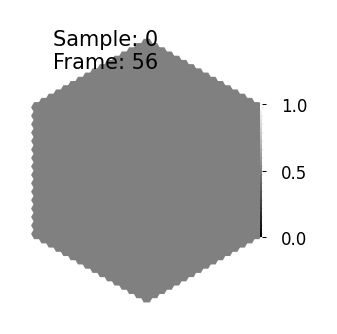

In [19]:
# visualize single sample
animation = HexScatter(
    dataset[0][None, ::10, None], vmin=0, vmax=1
)  # intensity=1, radius=6
animation.animate_in_notebook()

In [12]:
!flyvis download-pretrained

[2025-10-29 15:05:44] utils:164 NumExpr defaulting to 2 threads.
[2025-10-29 15:05:48] __init__:49 file_cache is only supported with oauth2client<4.0.0
Progress results_umap_and_clustering.zip: 100%
Checksum OK for results_umap_and_clustering.zip.
Unpacked results_umap_and_clustering.zip.
Progress results_pretrained_models.zip: 100%
Checksum OK for results_pretrained_models.zip.
Unpacked results_pretrained_models.zip.


## Network flash response

Now that we have generated the stimulus, we can use it to drive a trained connectome-constrained network.

In [12]:
from flyvis import results_dir
from flyvis import NetworkView

# model are already sorted by task error
# we take the best task-performing model from the pre-sorted ensemble
network_view = NetworkView(results_dir / "flow/0000/000")

In [20]:
stims_and_resps = network_view.flash_responses(dataset=dataset)

Batch:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
import pandas as pd

# 提取数据
data = stims_and_resps['responses'].custom.where(cell_type="Mi", radius=-1)

# 转换为 DataFrame
df = data.to_dataframe().reset_index()

# 查看 DataFrame 的结构
print("DataFrame 列名:", df.columns.tolist())
print("DataFrame 形状:", df.shape)
print("\n前几行数据:")
print(df.head())

# 保存为 Excel
df.to_excel('Tm3_flash4_responses_detailed.xlsx', index=False)

DataFrame 列名: ['network_id', 'sample', 'frame', 'neuron', 'baseline', 'intensity', 'radius', 'stim_type', 'time', 'cell_type', 'u', 'v', 'network_name', 'checkpoints', 'responses']
DataFrame 形状: (650, 15)

前几行数据:
   network_id  sample  frame  neuron  baseline  intensity  radius  \
0           0       0      0      45       0.0        1.0      -1   
1           0       0      1      45       0.0        1.0      -1   
2           0       0      2      45       0.0        1.0      -1   
3           0       0      3      45       0.0        1.0      -1   
4           0       0      4      45       0.0        1.0      -1   

       stim_type  time cell_type  u  v   network_name  \
0  flash4_bright -1.99       Tm3  0  0  flow/0000/000   
1  flash4_bright -1.98       Tm3  0  0  flow/0000/000   
2  flash4_bright -1.97       Tm3  0  0  flow/0000/000   
3  flash4_bright -1.96       Tm3  0  0  flow/0000/000   
4  flash4_bright -1.95       Tm3  0  0  flow/0000/000   

                             

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Flash response index (FRI)

The flash response index (FRI) is a measure of the strength of contrast tuning of a particular cell. It is computed as the difference between the cell's peak voltage in response to on-flashes (intensity = 1) and off-flashes (intensity = 0), divided by the sum of those peak values.

That is, given a single neuron's response to on-flashes `r_on` and off-flashes `r_off` (both of `shape=(T,)`), we can compute the flash response index with

```
r_on_max = max(r_on)
r_off_max = max(r_off)
fri = (r_on_max - r_off_max) / (r_on_max + r_off_max + 1e-16)
```

with the additional `1e-16` simply for numerical stability. Before this calculation, the response traces are shifted to be non-negative.

The flash response index can take on values between $-1$, when the off response is much stronger (or more positive) than the on response, to $1$, when the on response is much stronger (or more positive) than the off response.

For the L1 cell plotted before, we can see that it displays a positive response to off flashes and a negative response to on flashes, so we expect a negative flash response index.

In [ ]:
from flyvis.analysis.flash_responses import flash_response_index

In [ ]:
fris = flash_response_index(stims_and_resps, radius=6)

In [ ]:
fris.custom.where(cell_type="L1")

### FRI correlation

Since the tuning of some cell types have been determined experimentally, we can then compare our model to experimental findings by computing the correlation between the model FRIs for known cell types with their expected tuning.

In [ ]:
from flyvis.analysis.flash_responses import fri_correlation_to_known
from flyvis.utils.groundtruth_utils import polarity

In [ ]:
fri_corr = fri_correlation_to_known(fris)

In [ ]:
# manually extract model and true FRIs for plotting
known_cell_types = [k for k, v in polarity.items() if v != 0]
model_fris = [fris.custom.where(cell_type=k).item() for k in known_cell_types]
true_fris = [polarity[k] for k in known_cell_types]
# plot
plt.figure(figsize=[2, 1])
plt.scatter(model_fris, true_fris, color="k", s=10)
plt.xlabel("predicted FRI")
plt.ylabel("putative FRI (true tuning)")
plt.axvline(0, linestyle="--", color="black")
plt.axhline(0, linestyle="--", color="black")

plt.axhspan(0, 2, 0, 0.5, color="red", zorder=-10)
plt.axhspan(0, 2, 0.5, 1.0, color="green", zorder=-10)
plt.axhspan(-2, 0, 0, 0.5, color="green", zorder=-10)
plt.axhspan(-2, 0, 0.5, 1.0, color="red", zorder=-10)

plt.xlim(-1.05, 1.05)
plt.ylim(-2, 2)
plt.title(f"Correlation = {fri_corr[0].item():.2g}")
plt.yticks([-1, 1], ["OFF", "ON"])
plt.show()

As we can see, for all except two cell types, the model correctly predicts the cell's tuning (positive or negative).

## Ensemble responses

Now we can compare tuning properties across an ensemble of trained models. First we need to again simulate the network responses.

In [ ]:
from flyvis import EnsembleView

ensemble = EnsembleView("flow/0000")

In [ ]:
stims_and_resps = ensemble.flash_responses(dataset=dataset)

### Response traces

We can once again plot response traces for a single cell type. We subtract the initial value of each trace to center the data before plotting, as the network neuron activities are in arbitrary units.

In [ ]:
centered = (
    stims_and_resps['responses']
    - stims_and_resps['responses'].custom.where(time=0.0).values
)

In [ ]:
centered.sel(network_id=ensemble.argsort()[:10]).custom.where(
    cell_type="L1", radius=6, intensity=1
).custom.plot_traces(x='time', plot_kwargs=dict(color='orange', linewidth=0.5))
ax = plt.gca()
centered.sel(network_id=ensemble.argsort()[:10]).custom.where(
    cell_type="L1", radius=6, intensity=0
).custom.plot_traces(x='time', plot_kwargs=dict(ax=ax, color='blue', linewidth=0.5))
ax.set_title("L1 flash responses")

Though the scaling varies, all networks predict depolarization to OFF-flashes for L1.

### Flash response index (FRI)

We can also compute flash response indices for each network in the ensemble.

In [ ]:
# get FRI for L1 cell

fri_l1 = (
    flash_response_index(stims_and_resps, radius=6)
    .sel(network_id=ensemble.argsort()[:10])
    .custom.where(cell_type="L1")
)
print(fri_l1.squeeze().values)

All models recover similar flash response indices for this cell type. We can also plot the distribution of FRIs per cell type across the ensemble.

In [ ]:
with ensemble.select_items(ensemble.argsort()[:10]):
    ensemble.flash_response_index()

### FRI correlation

Lastly, we look at the correlations to ground-truth tuning across the ensemble.

In [ ]:
from flyvis.analysis.flash_responses import flash_response_index

In [ ]:
fris = flash_response_index(stims_and_resps, radius=6)

In [ ]:
from flyvis.analysis.visualization.plots import violin_groups

# compute correlation
fri_corr = fri_correlation_to_known(fris)

fig, ax, *_ = violin_groups(
    np.array(fri_corr)[None, None, :].squeeze(-1),
    ylabel="FRI correlation",
    figsize=(2, 2),
    xlim=(0, 1),
    xticklabels=[],
    colors=[plt.get_cmap("Pastel1")(0.0)],
    scatter_edge_color="gray",
    scatter_radius=10,
)

Models in general have very good match to known single-neuron tuning properties, with median correlation around 0.8.